In [145]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [146]:
# TEMP IMPORTS
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.size"] = 16

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV, 
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

We chose option 1, the classification problem about whether a credit card client will default or not.

We chose this option because we were curious about how a machine learning model would be able to use the combination of different features given to identify something as ambiguous as whether someone would pay their credit card on time. When reading the associated research paper, it was interesting seeing real-world applications of the models we've been covering in class (like KNN, logistic regression, and classification trees), as well as how the resulting data was actually interpreted by researchers. We were also curious how our current implementation of SKLearn's models would perform compared to the (assumedly more advanced) ones used in the research paper and whether we would be able to replicate their results.

In [147]:
credit_df = pd.read_csv("data/UCI_Credit_Card.csv", index_col=0)
credit_df.shape
credit_df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [148]:
X = credit_df.drop(columns=["default.payment.next.month"], axis=1)
y = credit_df["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
X_train.shape

(21000, 23)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [149]:
credit_df.isnull().values.any()
print(credit_df["EDUCATION"].value_counts()) # 51
print(credit_df["MARRIAGE"].value_counts()) # 323 for 3, 54 for 0
print(credit_df["PAY_0"].value_counts())
print(credit_df["PAY_2"].value_counts()) 
print(credit_df["PAY_3"].value_counts())
print(credit_df["PAY_4"].value_counts()) 
print(credit_df["PAY_5"].value_counts()) 
print(credit_df["PAY_6"].value_counts()) 

num_defaulted = sum(credit_df["default.payment.next.month"])
print(num_defaulted) # 6636

print(credit_df["SEX"].value_counts()) 

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64


EDA:

First, we can analyze whether a column has any NaN values. Using isnull(), we see that no values inside the table are NaN. However, looking at the descriptions of each column on Kaggle, we can see that there are various values for unknown values, such as 6 for unknown EDUCATION, 3 and 0 for unspecified MARRIAGE status, and 9 for 9 months or more of PAY delay.

EDUCATION has 51 unknowns, MARRIAGE 377, all PAY 's have 0 values that are 9, so the impact of possible unknowns is fortunately relatively small when we consider that the total dataset has 30,000 entries.

We can also learn that out of the 30,000 entries, only 6636 entries resulted in the credit card being defaulted, meaning the data is quite imbalanced, so accuracy alone is probably not be the best indicator for determining a model's accuracy. Since this is a classification problem, we should instead evaluate the models using their precision, recall, and F1 scores alongside model accuracy.




Summary Statistics:
(Observed from the graphs shown on Kaggle)

1. 6636/30000 cases are default cases, meaning our dataset is imbalanced, meaning even a baseline model (like DummyClassifier) would only have an error of 22.12%.
2.  The ratio between men and women in the study is skewed towards women, with around 7000 more entries. 
3. Similarly, the age of people surveyed is heavily skewed towards people on the younger side, with the most common age range being 26.80-29.70. The imabalance could possibly indicate that credit card use is more common in younger people.
4. The mean for all PAY columns was negative, meaning the number of people paying their card on time (a value of -1) is enough to offset all of the people who have late payments of up to 9 or more months.

Text(0, 0.5, 'Number of Default Payments')

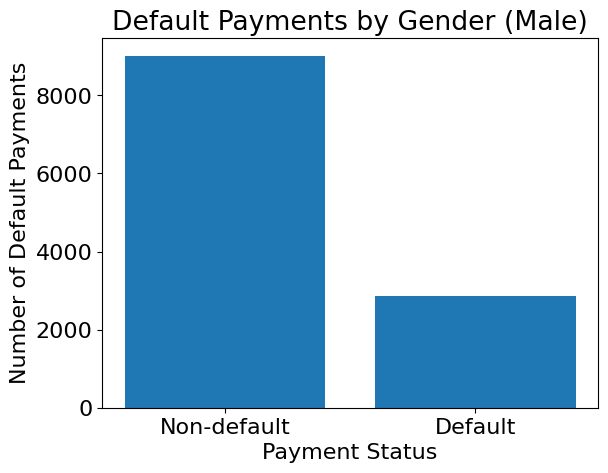

In [150]:
m_non = len(credit_df[(credit_df['SEX'] == 1) & (credit_df['default.payment.next.month'] == 0)])
m_def = len(credit_df[(credit_df['SEX'] == 1) & (credit_df['default.payment.next.month'] == 1)])
def_counts = [m_non, m_def]
labels = ['Non-default', 'Default']

plt.bar(labels, def_counts)
plt.title("Default Payments by Gender (Male)")
plt.xlabel("Payment Status")
plt.ylabel("Number of Default Payments")

Text(0, 0.5, 'Number of Default Payments')

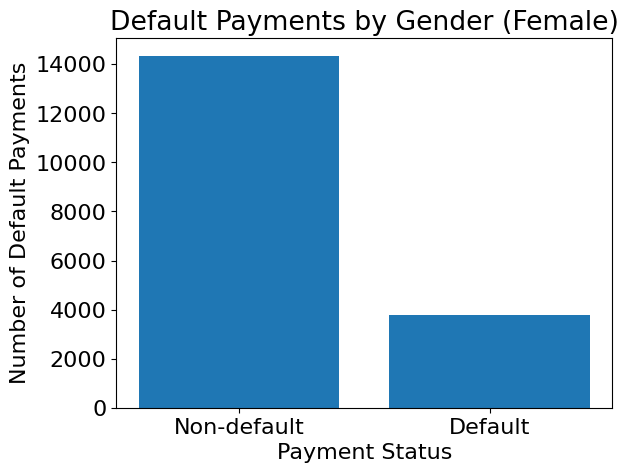

In [151]:
f_non = len(credit_df[(credit_df['SEX'] == 2) & (credit_df['default.payment.next.month'] == 0)])
f_def = len(credit_df[(credit_df['SEX'] == 2) & (credit_df['default.payment.next.month'] == 1)])
non_counts = [f_non, f_def]
labels = ['Non-default', 'Default']
plt.bar(labels, non_counts)
plt.title("Default Payments by Gender (Female)")
plt.xlabel("Payment Status")
plt.ylabel("Number of Default Payments")

Since the ratio between non-default payments and default payments is relatively similar for both genders, it indicates that there's not a strong correlation between gender and the likeliness of the person defaulting a payment alone. We'll keep gender as a feature for now because it's possible that gender in combination with the other features may have a big impact on the predictions of the model. 

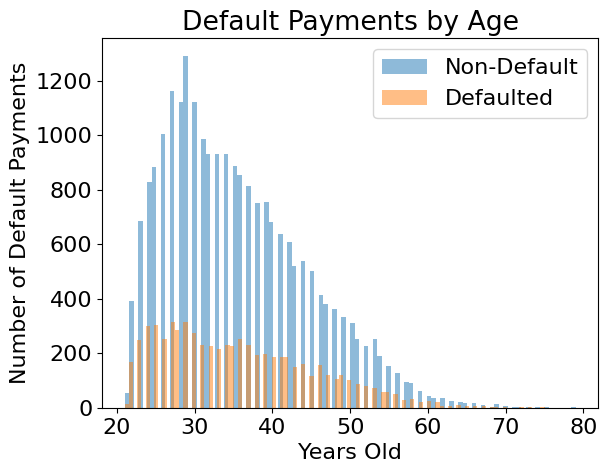

In [152]:
age_non = credit_df[credit_df['default.payment.next.month']==0]
age_def=credit_df[credit_df['default.payment.next.month']==1]

plt.hist(age_non['AGE'], bins=100, alpha=0.5, label='Non-Default')
plt.hist(age_def['AGE'], bins=100, alpha=0.5, label='Defaulted')
plt.title("Default Payments by Age")
plt.xlabel("Years Old")
plt.ylabel("Number of Default Payments")
plt.legend(loc='upper right')

Similarly, when we look at the age distribution of those that paid on time and compare it to those that defaulted payments, their distributions are very similar. Both show a trend towards a higher number of younger credit card users, with a much less dramatic peak in those that defaulted payments, possibly indicating that someone who defaults a payment may do it regardless of age. In fact, the ratio of older credit card users that default payments compared to older credit card users that pay on time is significantly higher than younger credit card users.

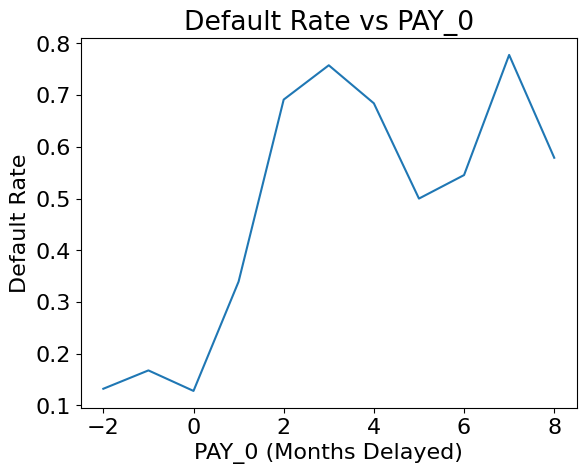

In [153]:
default_rate = credit_df.groupby("PAY_0")["default.payment.next.month"].mean()

plt.plot(default_rate.index, default_rate.values)
plt.xlabel("PAY_0 (Months Delayed)")
plt.ylabel("Default Rate")
plt.title("Default Rate vs PAY_0")
plt.show()

This graph of Default Rate vs PAY_0 shows that the default rate and pay status is heavily correlated with each other. Below, we see that this trend follows for the other PAY_ columns. 

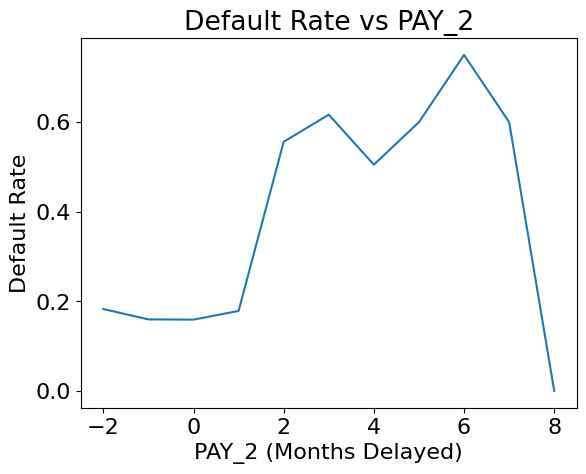

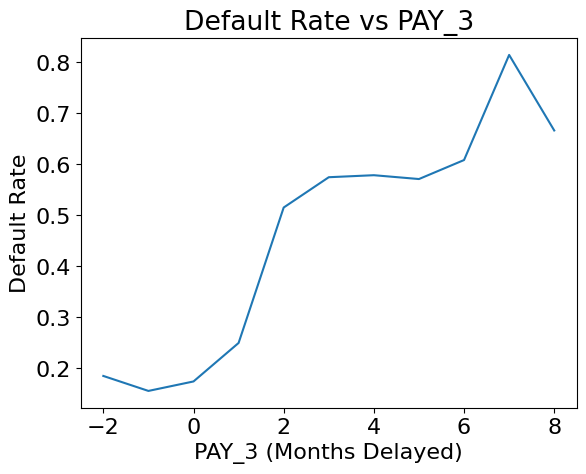

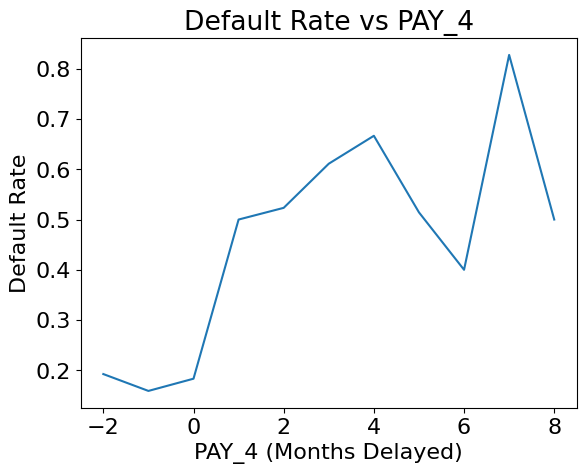

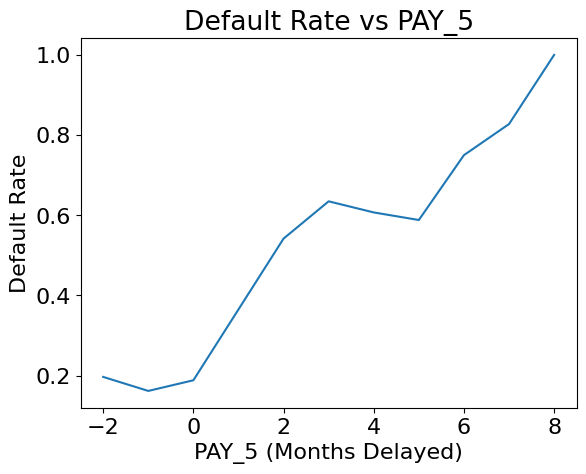

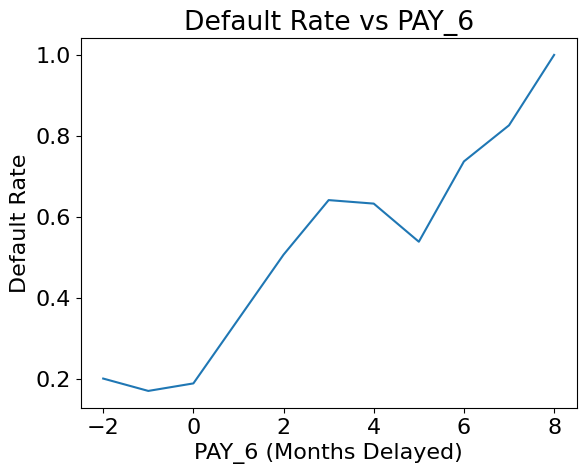

In [154]:
for i in range(2, 7):
    default_rate = credit_df.groupby(f"PAY_{i}")["default.payment.next.month"].mean()
    plt.plot(default_rate.index, default_rate.values)
    plt.xlabel(f"PAY_{i} (Months Delayed)")
    plt.ylabel("Default Rate")
    plt.title(f"Default Rate vs PAY_{i}")
    plt.show()

Initial Observations:

Overall, it's very difficult to interpret all of the columns alone, as seen by the similarity in graphs and previous analysis, with the exception of the PAY_X columns. These columns are shown to be heavily correlated with the default rate. The data also has quite a lot of skewing, both in some categories (age, gender) as well as the category we'll be trying to predict (default.payment.next.month). These factors might make it more difficult to interpret the data correctly, especially for machine models which are affected a lot by skewed data. For this reason, we'll likely have to do a lot of preprocessing on the data later. 

Fortunately, the data itself doesn't have any NaN values or many unknown values. The data can also be easily categorized into binary, numeric, categorical, and ordinal, which will make column processing much easier.

Evaluation Metrics:

Since the data is very imbalanced, we can't base model efficiency off accuracy alone. As this is a classification problem, we can use precision, recall, and F1-scores to judge models. Between recall and precision, if a model is unable to have both (low F1 score), recall is likely the more important score to consider as banks would likely prioritize detecting a higher amount of default risks (banks can't risk missing a true positive) rather than focusing on the precision of the default detections (false positives are not as risky for banks).

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [155]:
for i in range(1, 7):
    bill_col = f"BILL_AMT{i}"
    pay_col = f"PAY_AMT{i}"
    new_col = f"BILL_PAY{i}"
    X_train[new_col] = X_train[pay_col] / (X_train[bill_col] + 1e-5)
    X_test[new_col] = X_test[pay_col] / (X_test[bill_col] + 1e-5)

pay_cols = [f"PAY_{i}" for i in [0,2,3,4,5,6]]

X_train["MAX_DELAY"] = X_train[pay_cols].max(axis=1)
X_test["MAX_DELAY"] = X_test[pay_cols].max(axis=1)
X_train["NUM_DELAY"] = (X_train[pay_cols] > 0).sum(axis=1)
X_test["NUM_DELAY"] = (X_test[pay_cols] > 0).sum(axis=1)
X_train["AVG_DELAY"] = X_train[pay_cols].mean(axis=1)
X_test["AVG_DELAY"] = X_test[pay_cols].mean(axis=1)

It is hard to draw information from just payment amount, so we decided to combine bill amount and payment amount into columns that consists of the ratio between payment:bill amount.

As seen above, the PAY_X columns seem to have a strong correlation with the default rate. This made us inclined to extract useful generalizations from the 6 columns. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

Before making a preprocessor, we want to clean up the data to hopefully boost the performance of the models.

In [156]:
for df in [X_train, X_test]:
    df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4}).astype(str)

We decided to make an adjustment to the EDUCATION column. We changes all 5's and 6's into 4's. Functionally, 4, 5, and 6 have a very similar purpose, meaning that combining these categories will have little to no effect on performance.

In [157]:
numeric_features = [
    "LIMIT_BAL", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "BILL_PAY1","BILL_PAY2", "BILL_PAY3",
    "BILL_PAY4","BILL_PAY5", "BILL_PAY6",
    "MAX_DELAY", "NUM_DELAY", "AVG_DELAY"
]

ordinal_features = ["EDUCATION"]

binary_features = ["SEX"]

categorical_features = ["MARRIAGE"]

In [158]:
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

education_levels = [['4', '3', '2', '1']]

ordinal_transformer = OrdinalEncoder(categories=education_levels)

binary_transformer = OneHotEncoder(drop="if_binary", dtype=int)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

In [159]:
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (ordinal_transformer, ordinal_features),
    (binary_transformer, binary_features),
    (categorical_transformer, categorical_features),
)

In [160]:
credit_df.head()
X_train_pp = preprocessor.fit(X_train)
column_names = preprocessor.get_feature_names_out()
X_train_pp = pd.DataFrame(preprocessor.transform(X_train),
                            columns = column_names,
                            index=X_train.index
                        )
X_train_pp

,pipeline-1__LIMIT_BAL,pipeline-1__AGE,pipeline-1__PAY_0,pipeline-1__PAY_2,pipeline-1__PAY_3,pipeline-1__PAY_4,pipeline-1__PAY_5,pipeline-1__PAY_6,pipeline-1__BILL_AMT1,pipeline-1__BILL_AMT2,...,pipeline-1__BILL_PAY6,pipeline-1__MAX_DELAY,pipeline-1__NUM_DELAY,pipeline-1__AVG_DELAY,ordinalencoder__EDUCATION,onehotencoder__SEX_2,pipeline-2__MARRIAGE_0,pipeline-2__MARRIAGE_1,pipeline-2__MARRIAGE_2,pipeline-2__MARRIAGE_3
ID,,,,,,,,,,,,,,,,,,,,,
16396,1.168355,0.054187,0.013770,0.114774,0.143483,0.192754,0.232531,0.257059,-0.300665,-0.293394,...,-0.052235,-0.325570,-0.534714,0.188425,3.0,1.0,0.0,0.0,1.0,0.0
21449,2.090017,-0.597108,-0.878738,-0.722412,-0.692571,0.192754,0.232531,0.257059,-0.685307,-0.679495,...,-0.052235,-0.325570,-0.534714,-0.321334,3.0,1.0,0.0,0.0,1.0,0.0
20035,-0.060527,0.922579,-1.771246,-1.559598,-1.528626,-1.518801,-1.526210,-1.485154,-0.696132,-0.688319,...,-0.052235,-1.816079,-0.534714,-1.850612,1.0,1.0,0.0,1.0,0.0,0.0
25756,-0.367748,-0.597108,0.013770,0.114774,0.143483,0.192754,0.232531,0.257059,0.687456,0.752583,...,-0.052235,-0.325570,-0.534714,0.188425,2.0,1.0,0.0,1.0,0.0,0.0
1439,-0.905384,2.008070,0.906278,1.789147,0.143483,0.192754,0.232531,0.257059,-0.040230,-0.031399,...,-0.052235,1.164940,0.755826,0.698184,2.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28637,1.629186,0.162736,0.013770,0.114774,0.143483,0.192754,0.232531,1.999273,-0.513226,-0.486648,...,-0.052235,1.164940,0.110556,0.528264,2.0,1.0,0.0,1.0,0.0,0.0
17731,1.475576,2.008070,0.906278,-1.559598,-1.528626,-0.663024,0.232531,-0.614047,-0.695886,-0.688067,...,-0.052235,0.419685,0.110556,-0.661174,3.0,1.0,0.0,1.0,0.0,0.0
28031,-0.905384,-0.705657,0.013770,0.114774,0.143483,0.192754,0.232531,0.257059,-0.053288,-0.010446,...,-0.052235,-0.325570,-0.534714,0.188425,1.0,1.0,0.0,1.0,0.0,0.0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [161]:
dummy = DummyClassifier()


In [162]:
dummy.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [163]:
dummy.score(X_train, y_train)

0.7767619047619048

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

Since this is a classification problem, we'll be using a Logistic Regression Model. Overall, it didn't have the worst accuracy due to the data imabalance, but it could definitely be improved by hyperparameter tuning. Right now it's only performing about 3% better than the Dummy Classifier.

In [164]:
lr = LogisticRegression(random_state=123) # using default hyperparameters
pipe_lr = make_pipeline(preprocessor, lr)
scores = pd.DataFrame(cross_validate(pipe_lr, X_train, y_train, return_train_score=True))
scores.mean()

fit_time       0.096896
score_time     0.006844
test_score     0.809095
train_score    0.809702
dtype: float64

In [165]:
C_vals = [0.001, 0.01, 0.1, 1, 5, 10, 100]
pipe_lr = make_pipeline(preprocessor, LogisticRegression(random_state=123))
param_grid = {
    "logisticregression__C": C_vals,
    "logisticregression__max_iter" : Max_iter
}

grid_search = GridSearchCV(pipe_lr, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_C =  grid_search.best_params_.get("logisticregression__C")
best_Max_iter = grid_search.best_params_.get("logisticregression__max_iter")
best_score = grid_search.best_score_
best_C
best_score
best_Max_iter

100

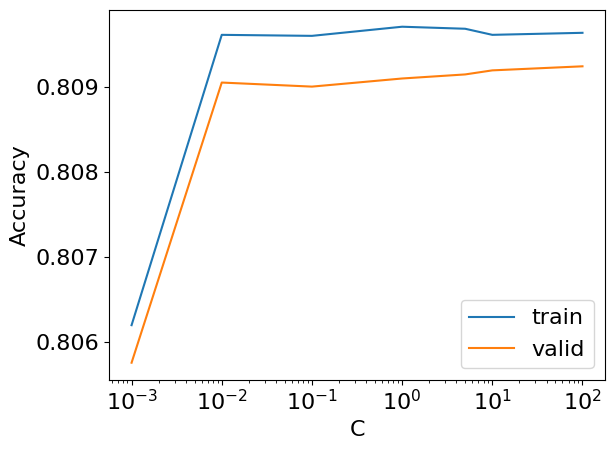

In [166]:
# taken from hw4
train_scores = []
cv_scores = []

for C in C_vals:
    #     print(C)
    pipe = make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=100, C=C, random_state=123),
    )
    cv_results = cross_validate(
        pipe, X_train, y_train,
        return_train_score=True
    )

    train_scores.append(cv_results["train_score"].mean())
    cv_scores.append(cv_results["test_score"].mean())
    std_scores.append(np.std(cv_scores))

plt.semilogx(C_vals, train_scores, label="train")
plt.semilogx(C_vals, cv_scores, label="valid")
plt.legend()
plt.xlabel("C")
plt.ylabel("Accuracy");

In [144]:
pd.DataFrame({"C": C_vals, "train": train_scores, "cv": cv_scores, "std": std_scores})

,C,train,cv,std
0,0.001,0.806202,0.805762,0.000000
1,0.010,0.809607,0.809048,0.001643
2,0.100,0.809595,0.809000,0.001538
3,1.000,0.809702,0.809095,0.001423
4,5.000,0.809679,0.809143,0.001325
5,10.000,0.809607,0.809190,0.001244
6,100.000,0.809631,0.809238,0.001177


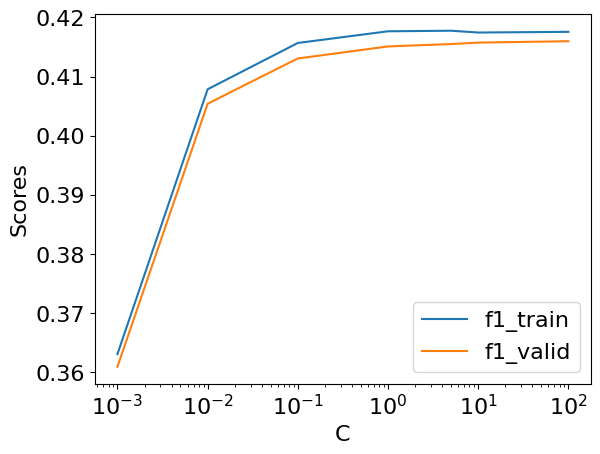

In [ ]:
# taken from hw4
f1_train_scores = []
f1_cv_scores = []
f1_std_scores = []
prec_train_scores = []
prec_cv_scores = []
rec_train_scores = []
rec_cv_scores = []

for C in C_vals:
    #     print(C)
    pipe = make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=100, C=C, random_state=123),
    )
    cv_results = cross_validate(
        pipe, X_train, y_train, 
        scoring=["f1", "precision", "recall"],
        return_train_score=True
    )

    f1_train_scores.append(cv_results["train_f1"].mean())
    f1_cv_scores.append(cv_results["test_f1"].mean())
    f1_std_scores.append(np.std(f1_cv_scores))
    prec_train_scores.append(cv_results["train_precision"].mean())
    prec_cv_scores.append(cv_results["test_precision"].mean())
    rec_train_scores.append(cv_results["train_recall"].mean())
    rec_cv_scores.append(cv_results["test_recall"].mean())

plt.semilogx(C_vals, f1_train_scores, label="f1_train")
plt.semilogx(C_vals, f1_cv_scores, label="f1_valid")
plt.legend()
plt.xlabel("C")
plt.ylabel("F1 Scores");

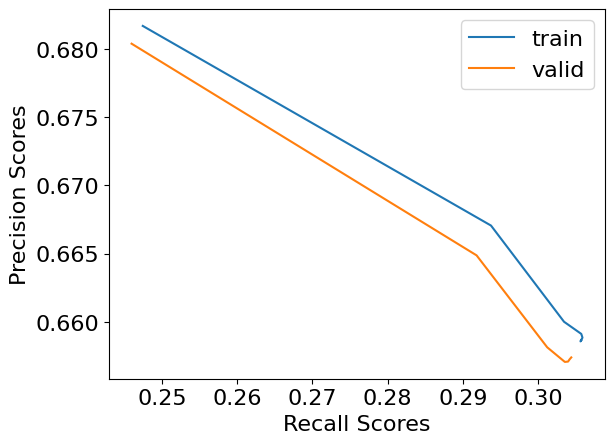

In [175]:
plt.plot(rec_train_scores, prec_train_scores, label="train")
plt.plot(rec_cv_scores, prec_cv_scores, label="valid")

plt.legend()
plt.xlabel("Recall Scores")
plt.ylabel("Precision Scores");

In [170]:
pd.DataFrame({"C": C_vals, "f1_train": f1_train_scores, "f1_cv": f1_cv_scores, "f1_std": f1_std_scores, "precision_train": prec_train_scores, "precision_cv": prec_cv_scores, "recall_train": rec_train_scores, "recall_cv": rec_cv_scores})

,C,f1_train,f1_cv,f1_std,precision_train,precision_cv,recall_train,recall_cv
0,0.001,0.363061,0.360926,0.000000,0.681666,0.680366,0.247440,0.245952
1,0.010,0.407839,0.405397,0.022236,0.667049,0.664867,0.293728,0.291811
2,0.100,0.415670,0.413051,0.022982,0.660007,0.658137,0.303434,0.301197
3,1.000,0.417645,0.415081,0.022057,0.659117,0.657066,0.305727,0.303543
4,5.000,0.417741,0.415491,0.020851,0.658844,0.657092,0.305887,0.303970
5,10.000,0.417435,0.415730,0.019711,0.658569,0.657261,0.305620,0.304183
6,100.000,0.417555,0.415966,0.018702,0.658647,0.657396,0.305727,0.304396


The best hyperparameter value for C was 10, as seen by the graph beginning to plateau for train and valid. The best hyperparameter value for max_iter was 100.

Overall, it seems like Logistic Regression isn't affected much by hyperparameter tuning. This makes sense as if relationships between different features are not linear, this model will have a lot of difficulty predicting an accurate outcome. 

This inability to predict trends in the data is especially obvious when we set class_weight='balanced' for our model in an attempt to offset the default imbalance.

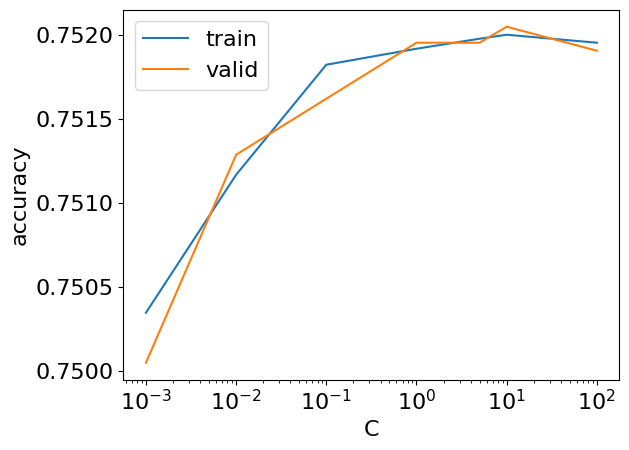

In [181]:
# taken from hw4
train_scores = []
cv_scores = []
std_scores = []

for C in C_vals:
    #     print(C)
    pipe = make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=100, C=C, random_state=123, class_weight='balanced'),
    )
    cv_results = cross_validate(pipe, X_train, y_train, return_train_score=True)

    train_scores.append(cv_results["train_score"].mean())
    cv_scores.append(cv_results["test_score"].mean())
    std_scores.append(np.std(cv_scores))

plt.semilogx(C_vals, train_scores, label="train")
plt.semilogx(C_vals, cv_scores, label="valid")
plt.legend()
plt.xlabel("C")
plt.ylabel("accuracy");

In [182]:
pd.DataFrame({"C": C_vals, "train": train_scores, "cv": cv_scores, "std": std_scores})

,C,train,cv,std
0,0.001,0.750345,0.750048,0.000000
1,0.010,0.751167,0.751286,0.000619
2,0.100,0.751821,0.751619,0.000676
3,1.000,0.751917,0.751952,0.000720
4,5.000,0.751976,0.751952,0.000707
5,10.000,0.752000,0.752048,0.000692
6,100.000,0.751952,0.751905,0.000658


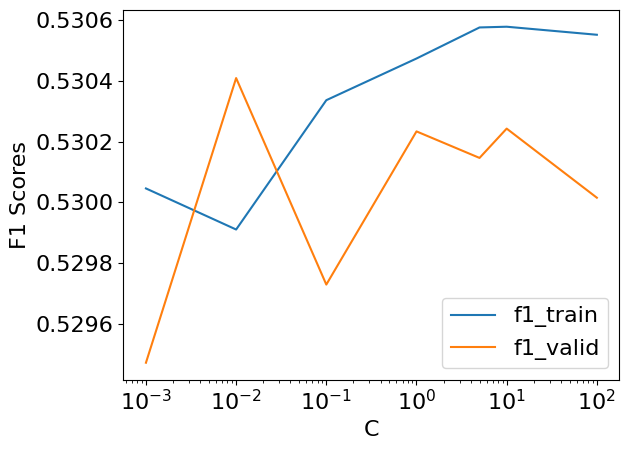

In [177]:
# taken from hw4
f1_train_scores = []
f1_cv_scores = []
f1_std_scores = []
prec_train_scores = []
prec_cv_scores = []
rec_train_scores = []
rec_cv_scores = []

for C in C_vals:
    #     print(C)
    pipe = make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=100, C=C, random_state=123, class_weight='balanced'),
    )
    cv_results = cross_validate(
        pipe, X_train, y_train, 
        scoring=["f1", "precision", "recall"],
        return_train_score=True
    )

    f1_train_scores.append(cv_results["train_f1"].mean())
    f1_cv_scores.append(cv_results["test_f1"].mean())
    f1_std_scores.append(np.std(f1_cv_scores))
    prec_train_scores.append(cv_results["train_precision"].mean())
    prec_cv_scores.append(cv_results["test_precision"].mean())
    rec_train_scores.append(cv_results["train_recall"].mean())
    rec_cv_scores.append(cv_results["test_recall"].mean())

plt.semilogx(C_vals, f1_train_scores, label="f1_train")
plt.semilogx(C_vals, f1_cv_scores, label="f1_valid")
plt.legend()
plt.xlabel("C")
plt.ylabel("F1 Scores");

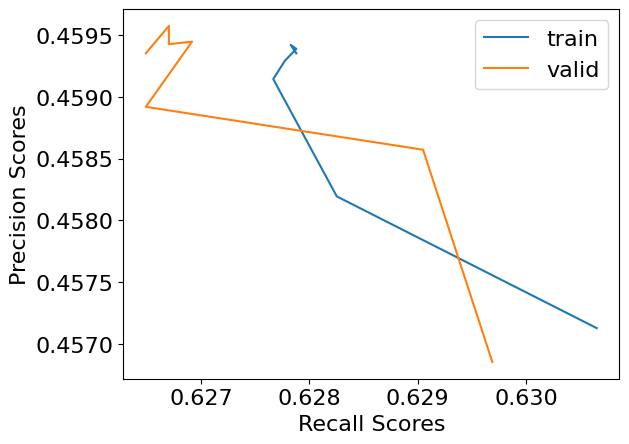

In [178]:
plt.plot(rec_train_scores, prec_train_scores, label="train")
plt.plot(rec_cv_scores, prec_cv_scores, label="valid")

plt.legend()
plt.xlabel("Recall Scores")
plt.ylabel("Precision Scores");

In [179]:
pd.DataFrame({"C": C_vals, "f1_train": f1_train_scores, "f1_cv": f1_cv_scores, "f1_std": f1_std_scores, "precision_train": prec_train_scores, "precision_cv": prec_cv_scores, "recall_train": rec_train_scores, "recall_cv": rec_cv_scores})

,C,f1_train,f1_cv,f1_std,precision_train,precision_cv,recall_train,recall_cv
0,0.001,0.530046,0.529471,0.000000,0.457126,0.456852,0.630652,0.629688
1,0.010,0.529910,0.530409,0.000469,0.458193,0.458571,0.628253,0.629049
2,0.100,0.530336,0.529729,0.000396,0.459143,0.458919,0.627666,0.626490
3,1.000,0.530474,0.530234,0.000377,0.459292,0.459447,0.627773,0.626916
4,5.000,0.530576,0.530146,0.000345,0.459389,0.459427,0.627879,0.626703
5,10.000,0.530579,0.530243,0.000328,0.459421,0.459574,0.627826,0.626703
6,100.000,0.530552,0.530015,0.000304,0.459353,0.459353,0.627879,0.626490


On balanced data the scores get pretty weird. Overall though, despite the overall accuracy of the model decreasing, The f1 and recall score seems to increase by a lot when the data is balanced, which is better for our usecase (as discussed in our EDA). 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [24]:
...

Ellipsis

In [25]:
...

Ellipsis

In [26]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [27]:
...

Ellipsis

In [28]:
...

Ellipsis

In [29]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [30]:
...

Ellipsis

In [31]:
...

Ellipsis

In [32]:
...

Ellipsis

In [33]:
...

Ellipsis

In [34]:
...

Ellipsis

In [35]:
...

Ellipsis

In [36]:
...

Ellipsis

In [37]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [38]:
...

Ellipsis

In [39]:
...

Ellipsis

In [40]:
...

Ellipsis

In [41]:
...

Ellipsis

In [42]:
...

Ellipsis

In [43]:
...

Ellipsis

In [44]:
...

Ellipsis

In [45]:
...

Ellipsis

In [46]:
...

Ellipsis

In [47]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [48]:
...

Ellipsis

In [49]:
...

Ellipsis

In [50]:
...

Ellipsis

In [51]:
...

Ellipsis

In [52]:
...

Ellipsis

In [53]:
...

Ellipsis

In [54]:
...

Ellipsis

In [55]:
...

Ellipsis

In [56]:
...

Ellipsis

In [57]:
...

Ellipsis

In [58]:
...

Ellipsis

In [59]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [60]:
...

Ellipsis

In [61]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)